In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

small_llm = ChatOpenAI(model="gpt-4o-mini")

In [3]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [4]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

In [5]:
from langchain_google_community import GmailToolkit
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="./google/token.json",
    scopes=["https://mail.google.com/"],
    client_secrets_file="./google/credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()

In [6]:
from langchain.agents import load_tools

loaded_tool_list = load_tools(
    ["arxiv"],
)

In [7]:
import os

from langchain_chroma import Chroma
from langchain_core.tools.retriever import create_retriever_tool
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='real_estate_tax',
    persist_directory='./real_estate_tax_collection'
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})
retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax up to December 2024',
)

In [8]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list + loaded_tool_list
llm_with_tools = small_llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [9]:
from langgraph.graph import MessagesState, StateGraph

class AgentState(MessagesState):
    summary: str

graph_builder = StateGraph(AgentState)

In [10]:
from langchain_core.messages import SystemMessage

def agent(state: AgentState) -> AgentState:
    messages = state['messages']
    summary = state['summary']
    if summary != '':
        messages = [SystemMessage(content=f'Here is the summary of the earlier conversation: {summary}')] + messages
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [11]:
from typing import Literal
from langgraph.types import interrupt, Command

# 세가지 타입의 액션 검증
# 1. LLM의 판단이 맞다면, 도구를 사용하기 위해 아무것도 수정하지 않고 `tools` 노드로 이동합니다
# 2. 도구는 잘 선택하였지만, 도구의 인자를 잘못 전달했다면, 도구의 인자를 수정하기 위해 `agent` 노드로 이동합니다
# 3. 도구를 잘못 선택하였을떄, 다른 도구를 사용하기 위해 `ToolMessage`를 업데이트합니다 
def human_review(state: AgentState) -> Command[Literal['tools', 'agent']]:
    messages = state['messages']
    last_message = messages[-1]
    tool_call = last_message.tool_calls[-1]
    # interrupt는 사용자에게 보여주고자 하는 메시지를 dictionary 형태로 작성한다.
    human_review = interrupt({
        'question': '이렇게 진행하면 될까요?',
        'tool_call': tool_call
    })
    review_action = human_review['action']
    review_data = human_review.get('data', None)
    
    if review_action == 'continue':
        # 에이전트의 판단이 맞다면, 도구를 사용하기 위해 아무것도 수정하지 않고 `tools` 노드로 이동합니다
        return Command(goto='tools')
    
    if review_action == 'update_args':
        # 도구를 더 효율적으로 사용하기 위해 AIMessage의 `tool_calls` 필드를 업데이트합니다
        updated_ai_message = {
            'id': last_message.id,
            'role': 'ai',
            'content': last_message.content,
            'tool_calls': [{
                'id': tool_call['id'],
                'name': tool_call['name'],
                'args': review_data
            }],
        }
        return Command(goto='tools', update={'messages': [updated_ai_message]})
    
    if review_action == 'update_tool':
        # 다른 도구를 사용하기 위해 `ToolMessage`를 업데이트합니다 
        updated_tool_message = {
            'tool_call_id': tool_call['id'],
            'name': tool_call['name'],
            'role': 'tool',
            'content': review_data
        }
        return Command(goto='agent', update={'messages': [updated_tool_message]})


In [12]:
def summarize_messages(state: AgentState):
    messages = state['messages']
    summary = state['summary']
    summary_prompt = f'summarize this chat history below: \n\nchat_history:{messages}'
    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversations
chat_history:{messages}
summary:{summary}'''
    
    summary = small_llm.invoke(summary_prompt)
    response = llm_with_tools.invoke(messages)
    return {'summary': response.content}

In [13]:
from langchain_core.messages import RemoveMessage

def delete_messages(state: AgentState):
    messages = state['messages']
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    return {'messages': delete_messages}

In [14]:
def should_continue(state: MessagesState):
    messages = state['messages']
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return 'human_review'
    
    return 'summarize_messages'

In [15]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node(human_review)
graph_builder.add_node(delete_messages)
graph_builder.add_node(summarize_messages)

In [16]:
from langgraph.graph import START, END


graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['human_review', 'summarize_messages']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_messages', 'delete_messages')
graph_builder.add_edge('delete_messages', END)

In [17]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

graph= graph_builder.compile(checkpointer=checkpointer)

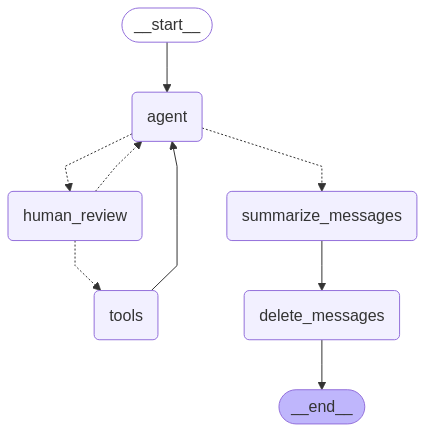

In [19]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'summarize_paper'
    }
}

query = 'LLM Survey 논문의 내용을 검색해서 요약해주세요'
for chunk in graph.stream({'messages': [HumanMessage(query)], 'summary': ''}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

LLM Survey 논문의 내용을 검색해서 요약해주세요
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_GLVxrzEGy2FGlUU1PSe6GPXV)
 Call ID: call_GLVxrzEGy2FGlUU1PSe6GPXV
  Args:
    query: LLM Survey


In [22]:
# 도구는 괜찮은데, args를 바꾸어야 할 경우
for chunk in graph.stream(
    Command(resume={"action": "update_tool", "data": "arxiv말고 web에서 검색해주세요"}),
    config,
    stream_mode="updates",
):
    print(chunk)

{'human_review': {'messages': [{'tool_call_id': 'call_GLVxrzEGy2FGlUU1PSe6GPXV', 'name': 'arxiv', 'role': 'tool', 'content': 'arxiv말고 web에서 검색해주세요'}]}}
{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_4GPqIHSZNVRE3JMZGHkpzHWm', 'function': {'arguments': '{"query":"LLM Survey paper summary"}', 'name': 'duckduckgo_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 779, 'total_tokens': 801, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f7d56a8a2c', 'id': 'chatcmpl-BOkjfMXYI8sWESxrrcm1j1Nlj9oz9', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-568a1127-0de3-489a-bc7f-2d220f0ecf5a-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query

In [23]:
# LLM 판단이 맞다면, 도구를 사용하기 위해 아무것도 수정하지 않고 `tools` 노드로 이동합니다
for chunk in graph.stream(
    Command(resume={"action": "continue"}),
    config,
    stream_mode="updates",
):
    print(f'chunk == {chunk}')

chunk == {'human_review': None}
chunk == {'tools': {'messages': [ToolMessage(content='This paper presents a comprehensive survey of the LLMs-as-judges paradigm from five key perspectives: Functionality, Methodology, Applications, Meta-evaluation, and Limitations. We begin by providing a systematic definition of LLMs-as-Judges and introduce their functionality (Why use LLM judges?). This paper provides a comprehensive survey of LLM-as-a-Judge, addressing the core question: How can reliable LLM-as-a-Judge systems be built? We explore strategies to enhance reliability, including improving consistency, mitigating biases, and adapting to diverse assessment scenarios. This survey paper explores the foundational components, scaling mechanisms, and architectural strategies that drive these capabilities. Emphasizing models like GPT and LLaMA, we analyze the impact of exponential data and computational growth on LLM performance, while also addressing the trade-offs associated with scaling. It is

In [24]:
graph.get_state(config).values['messages']

[AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_4GPqIHSZNVRE3JMZGHkpzHWm', 'function': {'arguments': '{"query":"LLM Survey paper summary"}', 'name': 'duckduckgo_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 779, 'total_tokens': 801, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f7d56a8a2c', 'id': 'chatcmpl-BOkjfMXYI8sWESxrrcm1j1Nlj9oz9', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-568a1127-0de3-489a-bc7f-2d220f0ecf5a-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'LLM Survey paper summary'}, 'id': 'call_4GPqIHSZNVRE3JMZGHkpzHWm', 'type': 'tool_call'}], usage_metadata={'input_tokens': 779, 'output_tokens': 22, 'total_tokens': 801, 'i